1. Imports 
2. Load Data
3. Explore Data
4. Clean Data
5. Visualization
6. Preprocessing
7. Models
8. Evaluation

In [ ]:
import pandas as pd

Load & explore dataset:

In [ ]:
df = pd.read_csv("spotify.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


Handle missing values:

In [ ]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Only a few missing - drop rows

In [ ]:
df = df.dropna()

Visualizations:

In [ ]:
import matplotlib.pyplot as plt

Distributions for columns:

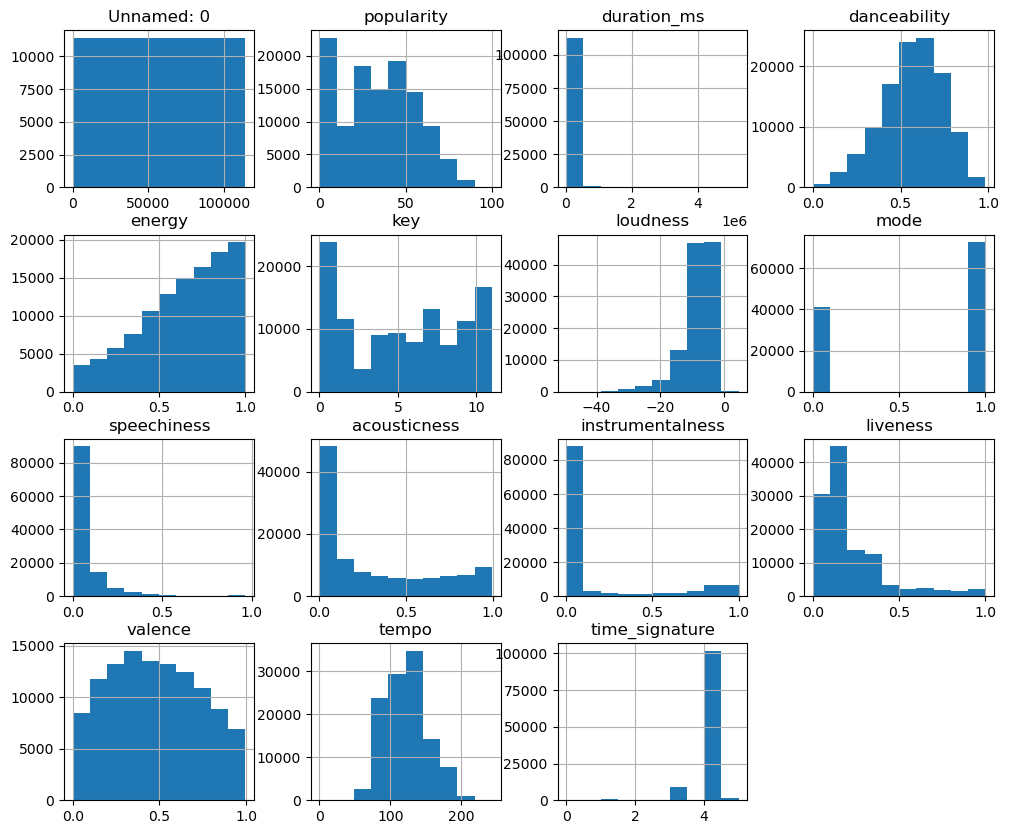

In [ ]:
df.hist(figsize=(12,10))
plt.show()

Target variable:

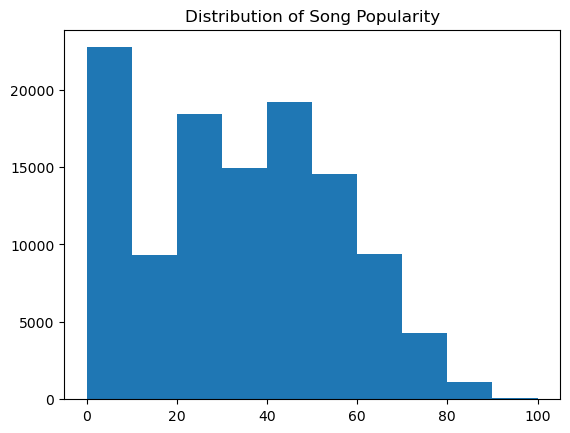

In [ ]:
plt.hist(df["popularity"])
plt.title("Distribution of Song Popularity")
plt.show()

Preprocessing:

Drop useless columns

In [ ]:
df = df.drop(columns=["track_id", "track_name", "artists", "album_name"])

Features & target

In [42]:
X = df.drop("popularity", axis=1)
y = df["popularity"]

Encode:

In [43]:
X = pd.get_dummies(X, drop_first=True)

Train/test split

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Scale features 

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Machine learning models:

Import

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

Linear regression model

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

lr_preds = lr.predict(X_test)

lr_r2 = r2_score(y_test, lr_preds)
lr_mse = mean_squared_error(y_test, lr_preds)
lr_rmse = np.sqrt(lr_mse)

print("Linear Regression R2:", lr_r2)
print("Linear Regression RMSE:", lr_rmse)


Linear Regression R2: 0.2622151593604213
Linear Regression RMSE: 19.13131707810919


Random forest regressor

In [ ]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
rf_preds = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_preds)
rf_mse = mean_squared_error(y_test, rf_preds)
rf_rmse = np.sqrt(rf_mse)

print("Random Forest R2:", rf_r2)
print("Random Forest RMSE:", rf_rmse)

Random Forest R2: 0.588865870668914
Random Forest RMSE: 14.281432482576317


Decision tree regressor

In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
dt_preds = dt.predict(X_test)

dt_r2 = r2_score(y_test, dt_preds)
dt_mse = mean_squared_error(y_test, dt_preds)
dt_rmse = np.sqrt(dt_mse)

print("Decision Tree R2:", dt_r2)
print("Decision Tree RMSE:", dt_rmse)

Decision Tree R2: 0.1880908930228874
Decision Tree RMSE: 20.069368734554377


Gradient boosting regressor

In [ ]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [ ]:
gb_preds = gb.predict(X_test)

gb_r2 = r2_score(y_test, gb_preds)
gb_mse = mean_squared_error(y_test, gb_preds)
gb_rmse = np.sqrt(gb_mse)

print("Gradient Boosting R2:", gb_r2)
print("Gradient Boosting RMSE:", gb_rmse)

Gradient Boosting R2: 0.22129918872869647
Gradient Boosting RMSE: 19.654650225105826


Support vector regressor

In [ ]:
svr = SVR()
svr.fit(X_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [ ]:
svr_preds = svr.predict(X_test)

svr_r2 = r2_score(y_test, svr_preds)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_preds))

print("SVR R2:", svr_r2)
print("SVR RMSE:", svr_rmse)

SVR R2: 0.19377551242635682
SVR RMSE: 19.998987013262447


Neural network (MLP regressor)

In [ ]:
mlp = MLPRegressor(random_state=42, max_iter=500)
mlp.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,loss,'squared_error'
,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True


In [ ]:
mlp_preds = mlp.predict(X_test)

mlp_r2 = r2_score(y_test, mlp_preds)
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_preds))

print("MLP R2:", mlp_r2)
print("MLP RMSE:", mlp_rmse)

MLP R2: 0.31719634901297167
MLP RMSE: 18.404665270427046


In [ ]:
results = {
    "Linear Regression": {"R2": lr_r2, "RMSE": lr_rmse},
    "Random Forest": {"R2": rf_r2, "RMSE": rf_rmse},
    "Decision Tree": {"R2": dt_r2, "RMSE": dt_rmse},
    "Gradient Boosting": {"R2": gb_r2, "RMSE": gb_rmse},
    "SVR": {"R2": svr_r2, "RMSE": svr_rmse},
    "Neural Network": {"R2": mlp_r2, "RMSE": mlp_rmse},
}

results_df = pd.DataFrame(results).T
print(results_df)

                         R2       RMSE
Linear Regression  0.262215  19.131317
Random Forest      0.588866  14.281432
Decision Tree      0.188091  20.069369
Gradient Boosting  0.221299  19.654650
SVR                0.193776  19.998987
Neural Network     0.317196  18.404665


Make sample df for hyperparameters

In [ ]:
df_sample = df.sample(n=20000, random_state=42)

In [41]:
X_sample = df_sample.drop("popularity", axis=1)
y_sample = df_sample["popularity"]

In [44]:
X_sample = pd.get_dummies(X_sample, drop_first=True)

In [45]:
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_s)
X_test_s = scaler.transform(X_test_s)

Hyperparameters: The top 3 models were selected based on their performance on the test set, using R^2 and RMSE as evalluation metrics. Models with higher R^2 and lower RMSE were considered superior.

Random forest:

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train_s, y_train_s)

print("Best RF Params:", rf_grid.best_params_)

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


Neural network:

In [51]:
mlp_params = {
    "hidden_layer_sizes": [(50,), (100,), (50,50)],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.001, 0.01]
}

mlp_grid = GridSearchCV(
    MLPRegressor(max_iter=500, random_state=42),
    mlp_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

mlp_grid.fit(X_train_s, y_train_s)

print("Best MLP Params:", mlp_grid.best_params_)

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

Best MLP Params: {'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001}


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Gradient boosting:

In [53]:
gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

gb_grid = GridSearchCV(gb, gb_params, cv=3, scoring="r2", n_jobs=-1)
gb_grid.fit(X_train_s, y_train_s)

print("Best GB Params:", gb_grid.best_params_)

Best GB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


Cross validation

RF

In [57]:
from sklearn.model_selection import cross_val_score

best_rf = RandomForestRegressor (**rf_grid.best_params_, random_state=42)
best_rf.fit(X_train, y_train)

rf_cv_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

print("RF CV R2:", rf_cv_scores.mean())

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0

RF CV R2: 0.5438529281581972


In [61]:
rf_cv_scores.mean()

np.float64(0.5438529281581972)

In [58]:
best_rf.fit(X_train, y_train)
rf_preds = best_rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print("Test R2:", rf_r2)
print("Test RMSE:", rf_rmse)

Test R2: 0.5901283697565625
Test RMSE: 14.259488113067402


MLP

In [60]:
best_mlp = MLPRegressor(**mlp_grid.best_params_, random_state=42, max_iter=500)

mlp_cv_scores = cross_val_score(
    best_mlp,
    X_train,
    y_train,
    cv=3,
    scoring = "r2",
    n_jobs=-1
)

print("MLP CV R2:", mlp_cv_scores.mean())

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

MLP CV R2: 0.2999222907446647


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [66]:
best_mlp.fit(X_train, y_train)
mlp_preds = best_mlp.predict(X_test)

mlp_r2 = r2_score(y_test, mlp_preds)
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_preds))

print("Test R2:", mlp_r2)
print("Test RMSE:", mlp_rmse)

Test R2: 0.3181861890275025
Test RMSE: 18.39132008597571


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


GB

In [69]:
best_gb = GradientBoostingRegressor(**gb_grid.best_params_, random_state=42)

gb_cv_scores = cross_val_score(
    best_gb,
    X_train,
    y_train,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

print("GB CV R2:", gb_cv_scores.mean())

0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0

GB CV R2: 0.3740654478708422


In [68]:
best_gb.fit(X_train, y_train)
gb_preds = best_gb.predict(X_test)

gb_r2 = r2_score(y_test, gb_preds)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))

print("Test R2:", gb_r2)
print("Test RMSE:", gb_rmse)

Test R2: 0.38378276050233673
Test RMSE: 17.484246792441276
